# 09 -- Distillation Dynamics

**Goal**: Deep analysis of KL distillation training dynamics using synthetic experiments.
No real teacher model required -- we study how temperature, alpha, student capacity,
learning rate, and gradient structure affect distillation convergence.

Experiments:
1. **Temperature sensitivity** -- T in [0.5, 1, 2, 4, 8]
2. **Alpha sensitivity** -- alpha in [0.1, 0.3, 0.5, 0.7, 0.9]
3. **Student capacity scaling** -- tiny/small configs vs same teacher
4. **Learning rate sweep** -- [1e-4, 3e-4, 1e-3, 3e-3] with cosine scheduling
5. **Gradient analysis** -- gradient norms per component during training

Wayy Research, 2024-2026.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd().parent.parent / "aetheris"))

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120
import json
import time
from collections import defaultdict
from dataclasses import dataclass

from aetheris import AetherisConfig, HybridMambaMoE
from aetheris.modules.ssm import SSMBlock
from aetheris.modules.moe import SparseMoELayer
from aya_distill.distill.cka import linear_cka

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cpu")
Path("../results").mkdir(exist_ok=True)

print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

# --- Global constants ---
VOCAB_SIZE = 5000
SEQ_LEN = 64
BATCH_SIZE = 8
N_STEPS = 200
TEACHER_D_MODEL = 512
TEACHER_LAYERS = 4

all_results = {}  # Collect everything for JSON export

Device: cpu
PyTorch: 2.10.0+cu128


## 1. Synthetic Teacher

A random `nn.TransformerEncoder` with d_model=512, 4 layers, and a tied embedding/lm_head.
We pre-train it briefly so it has non-trivial output distributions (not just uniform noise).

In [2]:
class SyntheticTeacher(nn.Module):
    """Lightweight transformer teacher for distillation experiments."""
    def __init__(self, vocab_size: int, d_model: int, n_layers: int, nhead: int = 8):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=0.0, batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.embedding.weight  # weight tying
        nn.init.normal_(self.embedding.weight, mean=0.0, std=0.02)
        self._causal_mask = None

    def _get_causal_mask(self, seq_len: int, device: torch.device) -> torch.Tensor:
        if self._causal_mask is None or self._causal_mask.shape[0] != seq_len:
            self._causal_mask = nn.Transformer.generate_square_subsequent_mask(
                seq_len, device=device
            )
        return self._causal_mask

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        x = self.embedding(input_ids)
        mask = self._get_causal_mask(input_ids.shape[1], input_ids.device)
        x = self.encoder(x, mask=mask, is_causal=True)
        return self.lm_head(x)


# Build and pre-train teacher
torch.manual_seed(42)
teacher = SyntheticTeacher(VOCAB_SIZE, TEACHER_D_MODEL, TEACHER_LAYERS, nhead=8)
t_params = sum(p.numel() for p in teacher.parameters())

t_optimizer = torch.optim.AdamW(teacher.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

print(f"Pre-training teacher ({t_params/1e6:.1f}M params) on random tokens...")
teacher.train()
for step in range(300):
    ids = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN))
    logits = teacher(ids)
    loss = loss_fn(logits[:, :-1].reshape(-1, VOCAB_SIZE), ids[:, 1:].reshape(-1))
    t_optimizer.zero_grad()
    loss.backward()
    t_optimizer.step()
    if step % 100 == 0:
        print(f"  Step {step}: loss={loss.item():.4f}")

teacher.eval()
for p in teacher.parameters():
    p.requires_grad = False
print(f"Teacher ready: {t_params/1e6:.1f}M params, {TEACHER_LAYERS} layers, d={TEACHER_D_MODEL}")

/tmp/ipykernel_347951/3306525713.py:10: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Pre-training teacher (15.2M params) on random tokens...


  Step 0: loss=8.6982


  Step 100: loss=8.6149


  Step 200: loss=8.6322


Teacher ready: 15.2M params, 4 layers, d=512


## 2. Training Utilities

Helper functions for distillation training loops, metric collection, and student construction.

In [3]:
def make_student(d_model: int = 256, n_layer: int = 4, num_experts: int = 2,
                 d_ff: int = 768) -> HybridMambaMoE:
    """Create a student model with given config."""
    cfg = AetherisConfig(
        vocab_size=VOCAB_SIZE,
        d_model=d_model,
        n_layer=n_layer,
        num_experts=num_experts,
        top_k=1,
        d_ff=d_ff,
        ssm_d_state=16,
        ssm_expand=2,
        max_seq_len=SEQ_LEN,
        gradient_checkpointing=False,
        dtype="float32",
    )
    return HybridMambaMoE(cfg)


def distill_train(
    student: HybridMambaMoE,
    teacher: nn.Module,
    temperature: float = 2.0,
    alpha: float = 0.7,
    lr: float = 3e-4,
    n_steps: int = N_STEPS,
    seed: int = 42,
    track_gradients: bool = False,
) -> dict:
    """Run a distillation training loop and collect metrics."""
    torch.manual_seed(seed)
    student.train()

    optimizer = torch.optim.AdamW(student.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_steps)

    metrics = {
        "kl_loss": [], "ce_loss": [], "total_loss": [],
        "top1_agreement": [],
    }
    if track_gradients:
        metrics["grad_norms"] = {"embedding": [], "ssm": [], "moe": [], "lm_head": []}

    for step in range(n_steps):
        input_ids = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN))
        labels = input_ids.clone()

        with torch.no_grad():
            teacher_logits = teacher(input_ids)

        output = student(input_ids, labels=labels)
        student_logits = output["logits"]
        ce_loss = output["ce_loss"]

        # Shifted logits for KL
        t_shift = teacher_logits[:, :-1, :].contiguous()
        s_shift = student_logits[:, :-1, :].contiguous()

        t_log_probs = F.log_softmax(t_shift / temperature, dim=-1)
        s_log_probs = F.log_softmax(s_shift / temperature, dim=-1)

        kl_loss = F.kl_div(
            s_log_probs.view(-1, VOCAB_SIZE),
            t_log_probs.view(-1, VOCAB_SIZE),
            log_target=True,
            reduction="batchmean",
        ) * (temperature ** 2)

        total_loss = alpha * kl_loss + (1 - alpha) * ce_loss + 0.01 * output["aux_loss"]

        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)

        # Gradient tracking
        if track_gradients:
            emb_norm = student.embedding.weight.grad.norm().item() if student.embedding.weight.grad is not None else 0.0
            ssm_norm, moe_norm = 0.0, 0.0
            ssm_count, moe_count = 0, 0
            for layer in student.layers:
                for p in layer.parameters():
                    if p.grad is not None:
                        gn = p.grad.norm().item()
                        if isinstance(layer, SSMBlock):
                            ssm_norm += gn
                            ssm_count += 1
                        elif isinstance(layer, SparseMoELayer):
                            moe_norm += gn
                            moe_count += 1
            lm_norm = student.lm_head.weight.grad.norm().item() if student.lm_head.weight.grad is not None else 0.0
            metrics["grad_norms"]["embedding"].append(emb_norm)
            metrics["grad_norms"]["ssm"].append(ssm_norm / max(ssm_count, 1))
            metrics["grad_norms"]["moe"].append(moe_norm / max(moe_count, 1))
            metrics["grad_norms"]["lm_head"].append(lm_norm)

        optimizer.step()
        scheduler.step()

        metrics["kl_loss"].append(kl_loss.item())
        metrics["ce_loss"].append(ce_loss.item())
        metrics["total_loss"].append(total_loss.item())

        # Top-1 agreement every 10 steps
        if step % 10 == 0:
            with torch.no_grad():
                t_pred = teacher_logits.argmax(dim=-1)
                s_pred = student_logits.argmax(dim=-1)
                agreement = (t_pred == s_pred).float().mean().item()
            metrics["top1_agreement"].append(agreement)

    # Final evaluation
    student.eval()
    final_kl_vals, final_agree_vals = [], []
    with torch.no_grad():
        for _ in range(20):
            ids = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, SEQ_LEN))
            t_logits = teacher(ids)
            s_logits = student(ids)["logits"]
            t_lp = F.log_softmax(t_logits / temperature, dim=-1)
            s_lp = F.log_softmax(s_logits / temperature, dim=-1)
            kl_val = F.kl_div(
                s_lp.view(-1, VOCAB_SIZE), t_lp.view(-1, VOCAB_SIZE),
                log_target=True, reduction="batchmean",
            ).item() * (temperature ** 2)
            final_kl_vals.append(kl_val)
            agree = (t_logits.argmax(-1) == s_logits.argmax(-1)).float().mean().item()
            final_agree_vals.append(agree)

    metrics["final_kl"] = float(np.mean(final_kl_vals))
    metrics["final_agreement"] = float(np.mean(final_agree_vals))
    return metrics


def smooth(arr, window=15):
    """Simple moving average."""
    if len(arr) < window:
        return arr
    return np.convolve(arr, np.ones(window)/window, mode='valid')

print("Utilities ready.")

Utilities ready.


## 3. Experiment 1: Temperature Sensitivity

How does the distillation temperature affect KL convergence speed, final KL, and teacher-student agreement?
Higher T softens the teacher distribution, exposing more "dark knowledge" but also making the signal noisier.

=== Temperature Sweep ===


  T= 0.5 | final_KL=0.0328 | agreement=26.9% | 164.0s


  T= 1.0 | final_KL=0.0332 | agreement=26.3% | 124.1s


  T= 2.0 | final_KL=0.0328 | agreement=24.7% | 151.6s


  T= 4.0 | final_KL=0.0327 | agreement=21.7% | 116.0s


  T= 8.0 | final_KL=0.0332 | agreement=19.2% | 63.5s


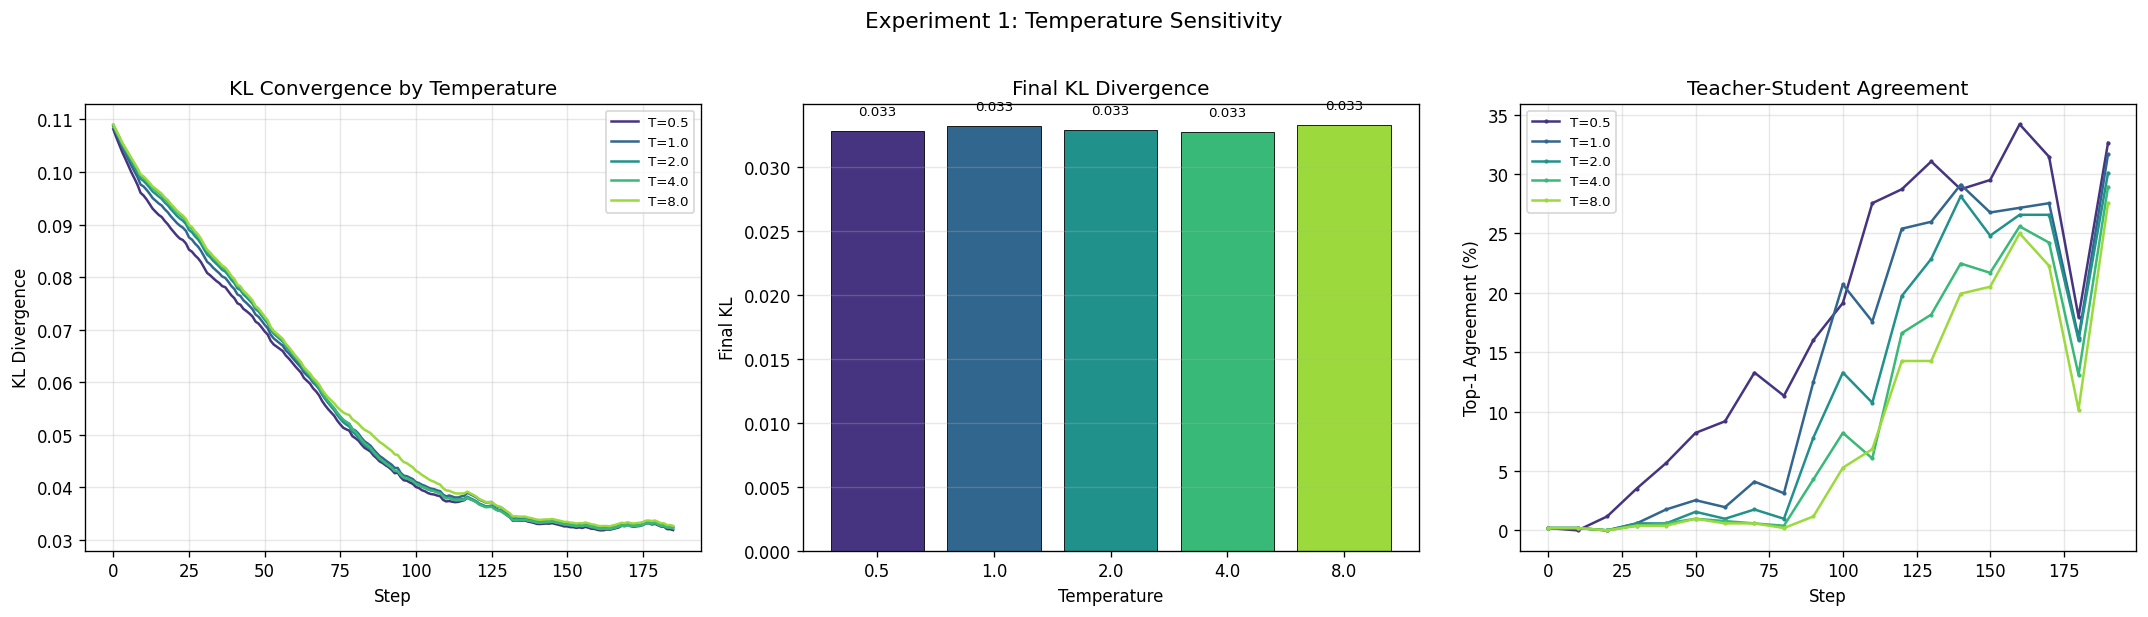

Saved: results/09_temperature_sensitivity.png


In [4]:
temperatures = [0.5, 1.0, 2.0, 4.0, 8.0]
temp_results = {}

print("=== Temperature Sweep ===")
for T in temperatures:
    t0 = time.time()
    student = make_student(d_model=256, n_layer=4)
    s_params = sum(p.numel() for p in student.parameters())
    metrics = distill_train(student, teacher, temperature=T, alpha=0.7, lr=3e-4)
    elapsed = time.time() - t0
    temp_results[T] = metrics
    print(f"  T={T:4.1f} | final_KL={metrics['final_kl']:.4f} | "
          f"agreement={metrics['final_agreement']*100:.1f}% | {elapsed:.1f}s")

all_results["temperature_sweep"] = {
    str(T): {"final_kl": m["final_kl"], "final_agreement": m["final_agreement"]}
    for T, m in temp_results.items()
}

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(temperatures)))

# KL convergence curves
ax = axes[0]
for T, c in zip(temperatures, colors):
    ax.plot(smooth(temp_results[T]["kl_loss"]), label=f"T={T}", color=c, linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("KL Divergence")
ax.set_title("KL Convergence by Temperature")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Final KL bar chart
ax = axes[1]
final_kls = [temp_results[T]["final_kl"] for T in temperatures]
bars = ax.bar([str(T) for T in temperatures], final_kls, color=colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Temperature")
ax.set_ylabel("Final KL")
ax.set_title("Final KL Divergence")
ax.grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, final_kls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8)

# Agreement curves
ax = axes[2]
for T, c in zip(temperatures, colors):
    agree = temp_results[T]["top1_agreement"]
    ax.plot(range(0, N_STEPS, 10)[:len(agree)], [a*100 for a in agree], label=f"T={T}",
            color=c, linewidth=1.5, marker=".", markersize=3)
ax.set_xlabel("Step")
ax.set_ylabel("Top-1 Agreement (%)")
ax.set_title("Teacher-Student Agreement")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("Experiment 1: Temperature Sensitivity", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../results/09_temperature_sensitivity.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: results/09_temperature_sensitivity.png")

## 4. Experiment 2: Alpha Sensitivity

Alpha controls the tradeoff between KL (soft-target) loss and CE (hard-label) loss.
High alpha means the student focuses on matching the teacher distribution;
low alpha means it focuses on getting the right answer.

=== Alpha Sweep ===


  alpha=0.1 | final_KL=0.1146 | final_CE=8.5741 | agreement=0.0% | 54.2s


  alpha=0.3 | final_KL=0.1090 | final_CE=8.5716 | agreement=0.0% | 49.5s


  alpha=0.5 | final_KL=0.0933 | final_CE=8.5681 | agreement=0.2% | 81.1s


  alpha=0.7 | final_KL=0.0328 | final_CE=8.5455 | agreement=24.7% | 94.6s


  alpha=0.9 | final_KL=0.0210 | final_CE=8.5547 | agreement=26.1% | 94.5s


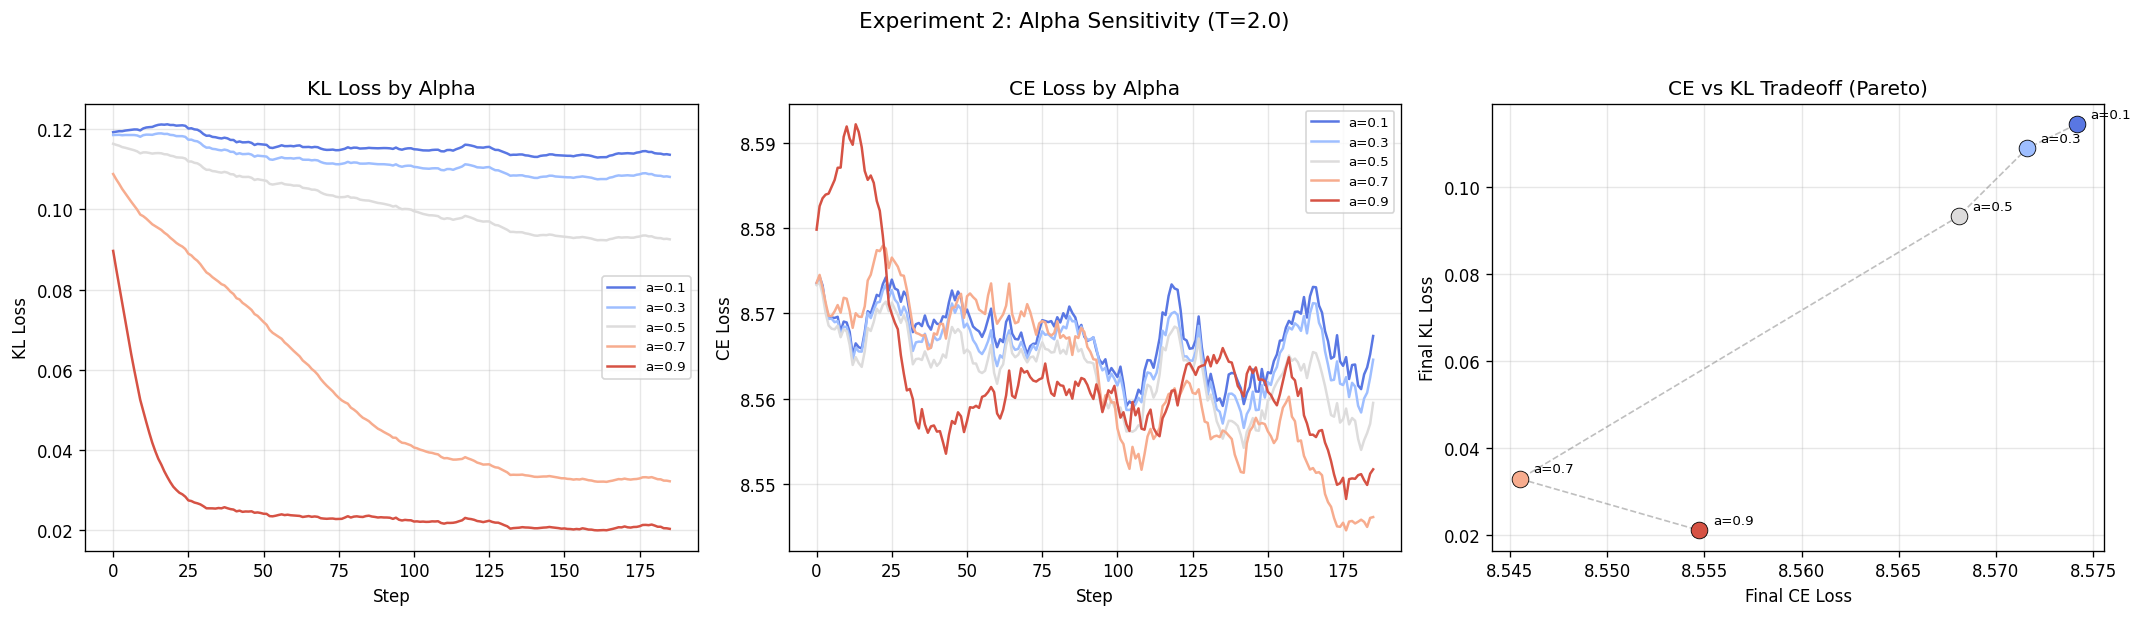

Saved: results/09_alpha_sensitivity.png


In [5]:
alphas = [0.1, 0.3, 0.5, 0.7, 0.9]
alpha_results = {}

print("=== Alpha Sweep ===")
for alpha in alphas:
    t0 = time.time()
    student = make_student(d_model=256, n_layer=4)
    metrics = distill_train(student, teacher, temperature=2.0, alpha=alpha, lr=3e-4)
    elapsed = time.time() - t0
    alpha_results[alpha] = metrics
    print(f"  alpha={alpha:.1f} | final_KL={metrics['final_kl']:.4f} | "
          f"final_CE={metrics['ce_loss'][-1]:.4f} | agreement={metrics['final_agreement']*100:.1f}% | {elapsed:.1f}s")

all_results["alpha_sweep"] = {
    str(a): {
        "final_kl": m["final_kl"],
        "final_ce": float(m["ce_loss"][-1]),
        "final_agreement": m["final_agreement"],
    }
    for a, m in alpha_results.items()
}

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(alphas)))

# CE vs KL tradeoff
ax = axes[0]
for a, c in zip(alphas, colors):
    ax.plot(smooth(alpha_results[a]["kl_loss"]), label=f"a={a}", color=c, linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("KL Loss")
ax.set_title("KL Loss by Alpha")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
for a, c in zip(alphas, colors):
    ax.plot(smooth(alpha_results[a]["ce_loss"]), label=f"a={a}", color=c, linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("CE Loss")
ax.set_title("CE Loss by Alpha")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Pareto plot: final KL vs final CE
ax = axes[2]
final_kls = [alpha_results[a]["final_kl"] for a in alphas]
final_ces = [alpha_results[a]["ce_loss"][-1] for a in alphas]
for a, kl, ce, c in zip(alphas, final_kls, final_ces, colors):
    ax.scatter(ce, kl, color=c, s=100, edgecolors="black", linewidths=0.5, zorder=5)
    ax.annotate(f"a={a}", (ce, kl), textcoords="offset points", xytext=(8, 4), fontsize=8)
ax.plot(final_ces, final_kls, "--", color="gray", alpha=0.5, linewidth=1)
ax.set_xlabel("Final CE Loss")
ax.set_ylabel("Final KL Loss")
ax.set_title("CE vs KL Tradeoff (Pareto)")
ax.grid(True, alpha=0.3)

plt.suptitle("Experiment 2: Alpha Sensitivity (T=2.0)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../results/09_alpha_sensitivity.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: results/09_alpha_sensitivity.png")

## 5. Experiment 3: Student Capacity Scaling

How does student model size affect distillation quality? We test three configs:
- **Tiny**: d=128, 2 layers, 2 experts
- **Small**: d=256, 4 layers, 2 experts
- **Medium**: d=256, 6 layers, 4 experts

All trained against the same synthetic teacher.

=== Capacity Scaling ===


  tiny    | 1.05M (14.5x) | final_KL=0.0579 | agreement=8.0% | 57.0s


  small   | 4.48M (3.4x) | final_KL=0.0334 | agreement=26.8% | 111.1s


  medium  | 8.44M (1.8x) | final_KL=0.0336 | agreement=10.4% | 79.1s


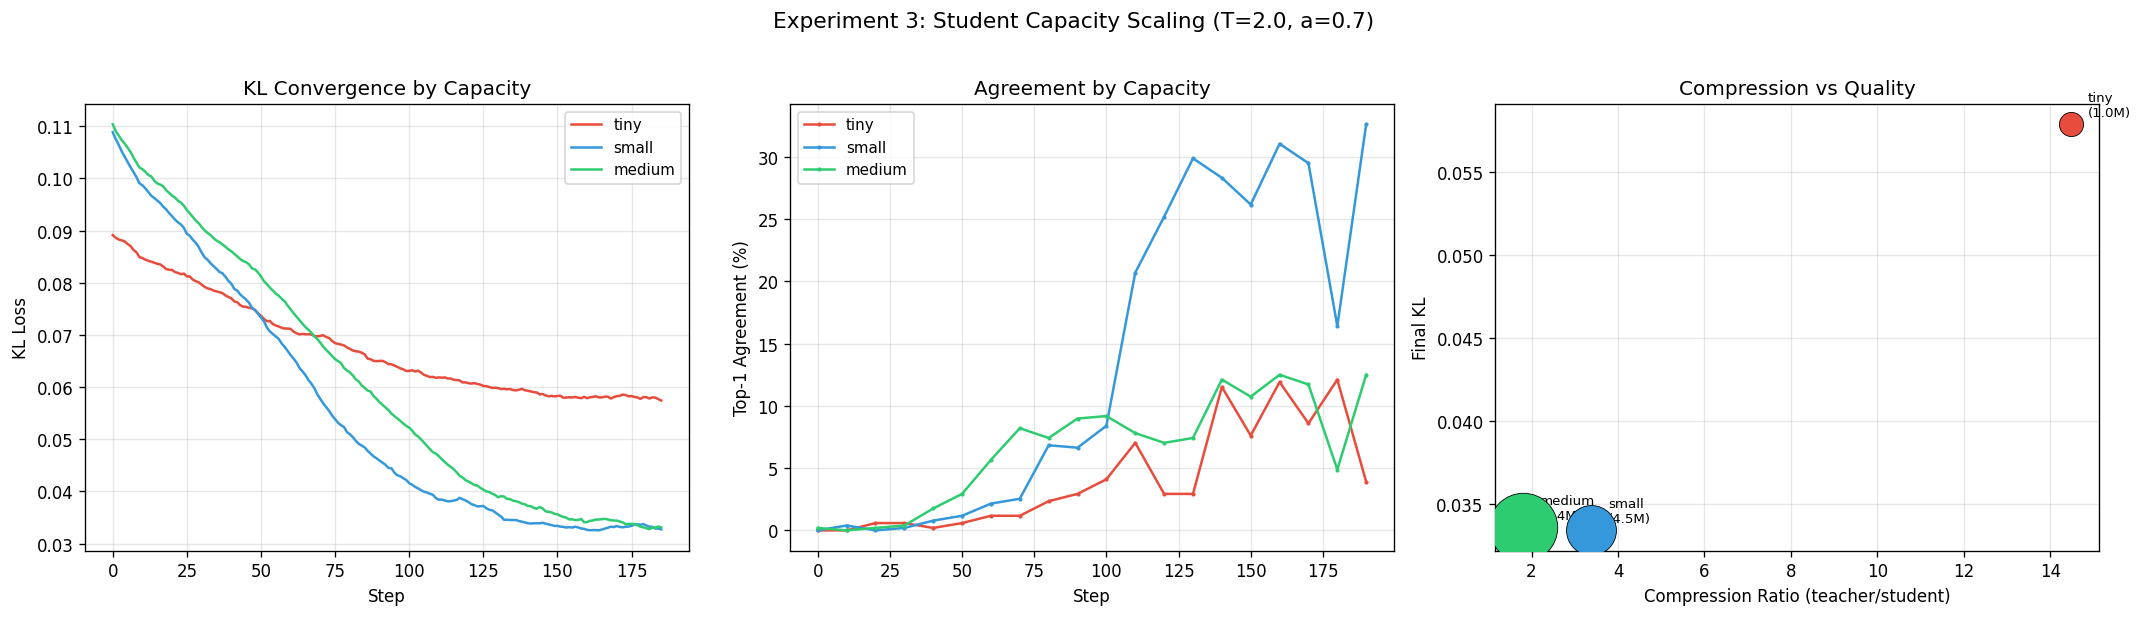

Saved: results/09_capacity_scaling.png


In [6]:
capacity_configs = {
    "tiny":   {"d_model": 128, "n_layer": 2, "num_experts": 2, "d_ff": 384},
    "small":  {"d_model": 256, "n_layer": 4, "num_experts": 2, "d_ff": 768},
    "medium": {"d_model": 256, "n_layer": 6, "num_experts": 4, "d_ff": 768},
}

capacity_results = {}
print("=== Capacity Scaling ===")
for name, cfg in capacity_configs.items():
    t0 = time.time()
    student = make_student(**cfg)
    s_params = sum(p.numel() for p in student.parameters())
    compression = t_params / s_params
    metrics = distill_train(student, teacher, temperature=2.0, alpha=0.7, lr=3e-4)
    elapsed = time.time() - t0
    metrics["params"] = s_params
    metrics["compression"] = compression
    capacity_results[name] = metrics
    print(f"  {name:7s} | {s_params/1e6:.2f}M ({compression:.1f}x) | "
          f"final_KL={metrics['final_kl']:.4f} | agreement={metrics['final_agreement']*100:.1f}% | {elapsed:.1f}s")

all_results["capacity_scaling"] = {
    name: {
        "params": m["params"],
        "compression": round(m["compression"], 2),
        "final_kl": m["final_kl"],
        "final_agreement": m["final_agreement"],
    }
    for name, m in capacity_results.items()
}

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cap_colors = {"tiny": "#e74c3c", "small": "#3498db", "medium": "#2ecc71"}

# KL convergence
ax = axes[0]
for name in capacity_configs:
    ax.plot(smooth(capacity_results[name]["kl_loss"]), label=name,
            color=cap_colors[name], linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("KL Loss")
ax.set_title("KL Convergence by Capacity")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Agreement
ax = axes[1]
for name in capacity_configs:
    agree = capacity_results[name]["top1_agreement"]
    ax.plot(range(0, N_STEPS, 10)[:len(agree)], [a*100 for a in agree],
            label=name, color=cap_colors[name], linewidth=1.5, marker=".", markersize=3)
ax.set_xlabel("Step")
ax.set_ylabel("Top-1 Agreement (%)")
ax.set_title("Agreement by Capacity")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Compression vs quality scatter
ax = axes[2]
for name in capacity_configs:
    m = capacity_results[name]
    ax.scatter(m["compression"], m["final_kl"], s=m["params"]/5000,
               color=cap_colors[name], edgecolors="black", linewidths=0.5, zorder=5)
    ax.annotate(f"{name}\n({m['params']/1e6:.1f}M)",
                (m["compression"], m["final_kl"]),
                textcoords="offset points", xytext=(10, 5), fontsize=8)
ax.set_xlabel("Compression Ratio (teacher/student)")
ax.set_ylabel("Final KL")
ax.set_title("Compression vs Quality")
ax.grid(True, alpha=0.3)

plt.suptitle("Experiment 3: Student Capacity Scaling (T=2.0, a=0.7)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../results/09_capacity_scaling.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: results/09_capacity_scaling.png")

## 6. Experiment 4: Learning Rate Sweep

How sensitive is distillation to learning rate? We test [1e-4, 3e-4, 1e-3, 3e-3]
with cosine annealing. Too high can cause instability; too low wastes steps.

=== Learning Rate Sweep ===


  lr=1e-04 | final_KL=0.0785 | agreement=3.6% | 60.0s


  lr=3e-04 | final_KL=0.0328 | agreement=24.7% | 55.8s


  lr=1e-03 | final_KL=0.0312 | agreement=23.6% | 60.3s


  lr=3e-03 | final_KL=0.0336 | agreement=21.0% | 64.0s


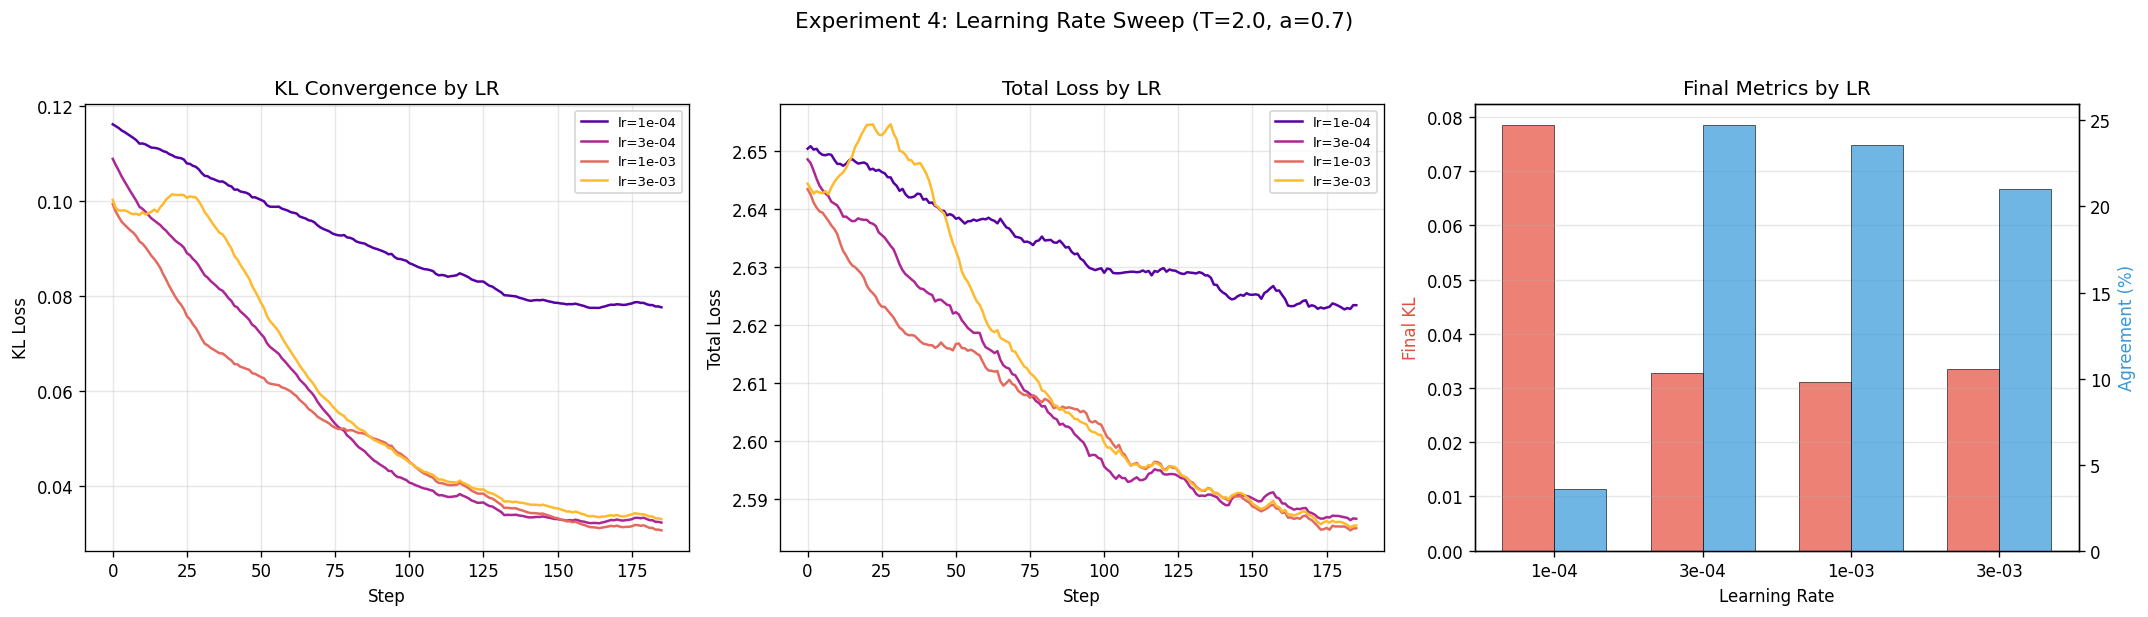

Saved: results/09_lr_sweep.png


In [7]:
learning_rates = [1e-4, 3e-4, 1e-3, 3e-3]
lr_results = {}

print("=== Learning Rate Sweep ===")
for lr in learning_rates:
    t0 = time.time()
    student = make_student(d_model=256, n_layer=4)
    metrics = distill_train(student, teacher, temperature=2.0, alpha=0.7, lr=lr)
    elapsed = time.time() - t0
    lr_results[lr] = metrics
    print(f"  lr={lr:.0e} | final_KL={metrics['final_kl']:.4f} | "
          f"agreement={metrics['final_agreement']*100:.1f}% | {elapsed:.1f}s")

all_results["lr_sweep"] = {
    f"{lr:.0e}": {"final_kl": m["final_kl"], "final_agreement": m["final_agreement"]}
    for lr, m in lr_results.items()
}

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(learning_rates)))

# KL convergence
ax = axes[0]
for lr, c in zip(learning_rates, colors):
    ax.plot(smooth(lr_results[lr]["kl_loss"]), label=f"lr={lr:.0e}", color=c, linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("KL Loss")
ax.set_title("KL Convergence by LR")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Total loss
ax = axes[1]
for lr, c in zip(learning_rates, colors):
    ax.plot(smooth(lr_results[lr]["total_loss"]), label=f"lr={lr:.0e}", color=c, linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("Total Loss")
ax.set_title("Total Loss by LR")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Final metrics bar chart
ax = axes[2]
lr_labels = [f"{lr:.0e}" for lr in learning_rates]
final_kls = [lr_results[lr]["final_kl"] for lr in learning_rates]
final_agrees = [lr_results[lr]["final_agreement"]*100 for lr in learning_rates]
x = np.arange(len(learning_rates))
w = 0.35
ax2 = ax.twinx()
ax.bar(x - w/2, final_kls, w, label="Final KL", color="#e74c3c", alpha=0.7, edgecolor="black", linewidth=0.5)
ax2.bar(x + w/2, final_agrees, w, label="Agreement %", color="#3498db", alpha=0.7, edgecolor="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(lr_labels)
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Final KL", color="#e74c3c")
ax2.set_ylabel("Agreement (%)", color="#3498db")
ax.set_title("Final Metrics by LR")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Experiment 4: Learning Rate Sweep (T=2.0, a=0.7)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../results/09_lr_sweep.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: results/09_lr_sweep.png")

## 7. Experiment 5: Gradient Analysis

Track gradient norms per component (SSM layers, MoE layers, embeddings, lm_head) during training.
This reveals which parts of the student are learning the most and potential gradient flow issues.

=== Gradient Analysis ===


  Steps tracked: 200
  embedding : mean=0.2423, std=0.0312, max=0.3103
  ssm       : mean=0.0036, std=0.0011, max=0.0062
  moe       : mean=0.0328, std=0.0168, max=0.0686
  lm_head   : mean=0.2423, std=0.0312, max=0.3103


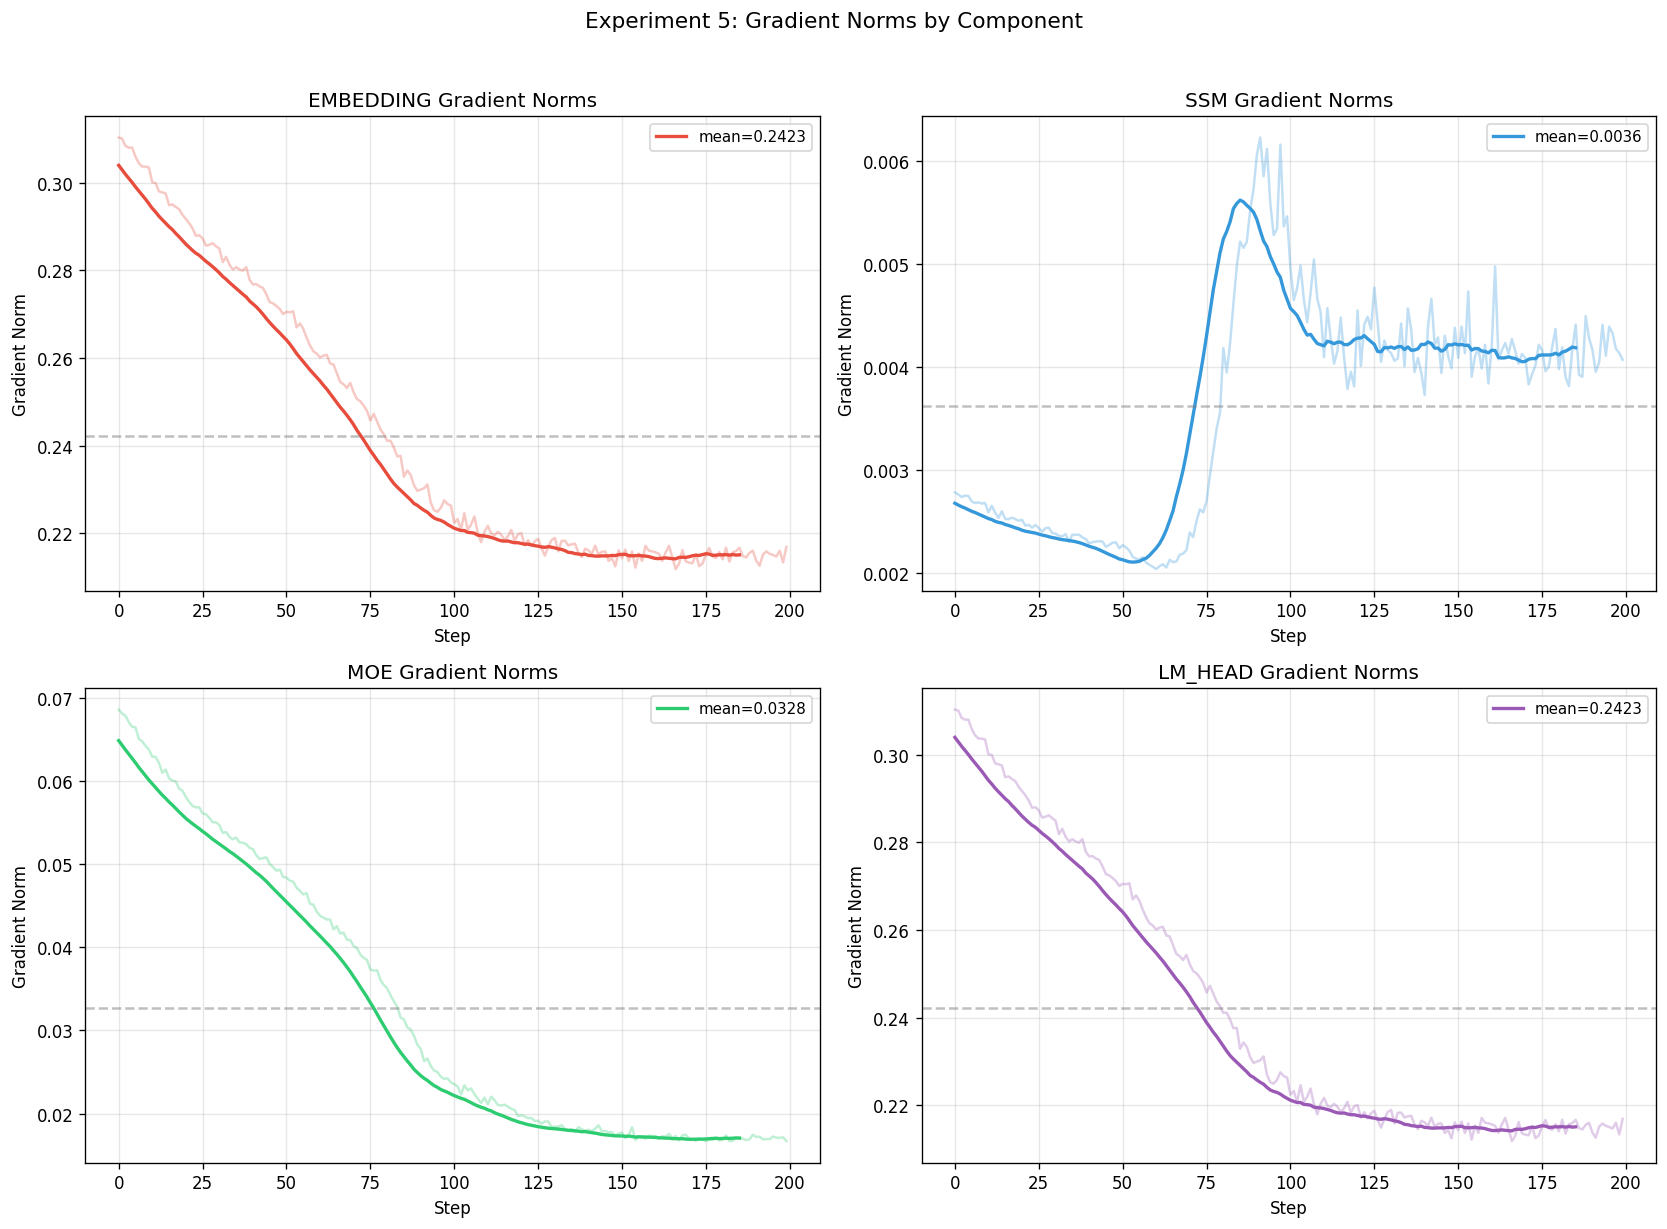

Saved: results/09_gradient_analysis.png


In [8]:
print("=== Gradient Analysis ===")
student = make_student(d_model=256, n_layer=4)
grad_metrics = distill_train(
    student, teacher, temperature=2.0, alpha=0.7, lr=3e-4, track_gradients=True
)

grad_norms = grad_metrics["grad_norms"]
print(f"  Steps tracked: {len(grad_norms['embedding'])}")
for comp in ["embedding", "ssm", "moe", "lm_head"]:
    vals = grad_norms[comp]
    print(f"  {comp:10s}: mean={np.mean(vals):.4f}, std={np.std(vals):.4f}, "
          f"max={np.max(vals):.4f}")

all_results["gradient_analysis"] = {
    comp: {
        "mean": round(float(np.mean(vals)), 6),
        "std": round(float(np.std(vals)), 6),
        "max": round(float(np.max(vals)), 6),
    }
    for comp, vals in grad_norms.items()
}

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
comp_colors = {"embedding": "#e74c3c", "ssm": "#3498db", "moe": "#2ecc71", "lm_head": "#9b59b6"}

for ax, comp in zip(axes.flat, ["embedding", "ssm", "moe", "lm_head"]):
    vals = grad_norms[comp]
    ax.plot(vals, alpha=0.3, color=comp_colors[comp])
    ax.plot(smooth(vals, window=15), color=comp_colors[comp], linewidth=2,
            label=f"mean={np.mean(vals):.4f}")
    ax.axhline(np.mean(vals), color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Step")
    ax.set_ylabel("Gradient Norm")
    ax.set_title(f"{comp.upper()} Gradient Norms")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Experiment 5: Gradient Norms by Component", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../results/09_gradient_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: results/09_gradient_analysis.png")

## 8. Gradient Ratio & Combined View

Overlay all component gradients on one plot and compute the ratio of SSM-to-MoE gradient norms.
If the ratio drifts far from 1.0, it suggests one component is dominating the learning signal.

Mean SSM/MoE gradient ratio: 0.1541


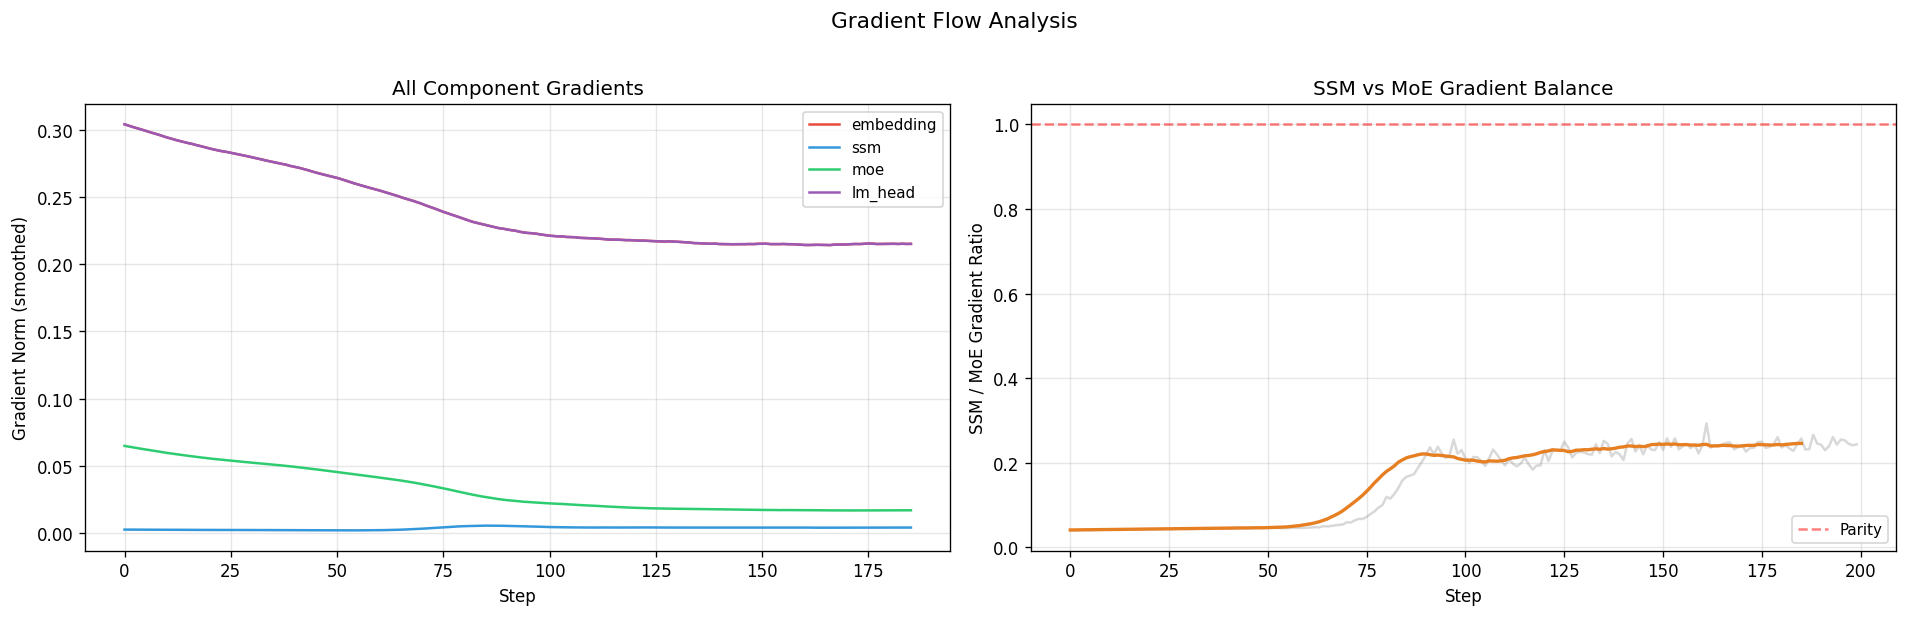

Saved: results/09_gradient_ratios.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overlay all components
ax = axes[0]
for comp in ["embedding", "ssm", "moe", "lm_head"]:
    ax.plot(smooth(grad_norms[comp], window=15), label=comp, color=comp_colors[comp], linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("Gradient Norm (smoothed)")
ax.set_title("All Component Gradients")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# SSM / MoE ratio
ax = axes[1]
ssm_arr = np.array(grad_norms["ssm"])
moe_arr = np.array(grad_norms["moe"])
ratio = ssm_arr / (moe_arr + 1e-10)
ax.plot(ratio, alpha=0.3, color="gray")
ax.plot(smooth(ratio, window=15), color="#e67e22", linewidth=2)
ax.axhline(1.0, color="red", linestyle="--", alpha=0.5, label="Parity")
ax.set_xlabel("Step")
ax.set_ylabel("SSM / MoE Gradient Ratio")
ax.set_title("SSM vs MoE Gradient Balance")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ssm_moe_ratio_mean = float(np.mean(ratio))
all_results["gradient_analysis"]["ssm_moe_ratio_mean"] = round(ssm_moe_ratio_mean, 4)
print(f"Mean SSM/MoE gradient ratio: {ssm_moe_ratio_mean:.4f}")

plt.suptitle("Gradient Flow Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../results/09_gradient_ratios.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: results/09_gradient_ratios.png")

## 9. Summary & Export

Consolidate all experimental results and save to JSON.

In [10]:
all_results["config"] = {
    "vocab_size": VOCAB_SIZE,
    "seq_len": SEQ_LEN,
    "batch_size": BATCH_SIZE,
    "n_steps": N_STEPS,
    "teacher_d_model": TEACHER_D_MODEL,
    "teacher_layers": TEACHER_LAYERS,
    "teacher_params": t_params,
    "seed": 42,
}

output_path = Path("../results/09_distillation_dynamics.json")
with open(output_path, "w") as f:
    json.dump(all_results, f, indent=2)

print("=" * 70)
print("DISTILLATION DYNAMICS -- SUMMARY")
print("=" * 70)

print("\n1. TEMPERATURE SENSITIVITY")
for T in temperatures:
    m = temp_results[T]
    print(f"   T={T:4.1f}: KL={m['final_kl']:.4f}, agreement={m['final_agreement']*100:.1f}%")

print("\n2. ALPHA SENSITIVITY")
for a in alphas:
    m = alpha_results[a]
    print(f"   a={a:.1f}: KL={m['final_kl']:.4f}, CE={m['ce_loss'][-1]:.4f}, agreement={m['final_agreement']*100:.1f}%")

print("\n3. CAPACITY SCALING")
for name in capacity_configs:
    m = capacity_results[name]
    print(f"   {name:7s}: {m['params']/1e6:.2f}M ({m['compression']:.1f}x), "
          f"KL={m['final_kl']:.4f}, agreement={m['final_agreement']*100:.1f}%")

print("\n4. LEARNING RATE SWEEP")
for lr in learning_rates:
    m = lr_results[lr]
    print(f"   lr={lr:.0e}: KL={m['final_kl']:.4f}, agreement={m['final_agreement']*100:.1f}%")

print("\n5. GRADIENT ANALYSIS")
for comp in ["embedding", "ssm", "moe", "lm_head"]:
    vals = grad_norms[comp]
    print(f"   {comp:10s}: mean={np.mean(vals):.4f}, max={np.max(vals):.4f}")
print(f"   SSM/MoE ratio: {ssm_moe_ratio_mean:.4f}")

print(f"\nResults saved: {output_path}")
print("Plots saved: results/09_*.png")

DISTILLATION DYNAMICS -- SUMMARY

1. TEMPERATURE SENSITIVITY
   T= 0.5: KL=0.0328, agreement=26.9%
   T= 1.0: KL=0.0332, agreement=26.3%
   T= 2.0: KL=0.0328, agreement=24.7%
   T= 4.0: KL=0.0327, agreement=21.7%
   T= 8.0: KL=0.0332, agreement=19.2%

2. ALPHA SENSITIVITY
   a=0.1: KL=0.1146, CE=8.5741, agreement=0.0%
   a=0.3: KL=0.1090, CE=8.5716, agreement=0.0%
   a=0.5: KL=0.0933, CE=8.5681, agreement=0.2%
   a=0.7: KL=0.0328, CE=8.5455, agreement=24.7%
   a=0.9: KL=0.0210, CE=8.5547, agreement=26.1%

3. CAPACITY SCALING
   tiny   : 1.05M (14.5x), KL=0.0579, agreement=8.0%
   small  : 4.48M (3.4x), KL=0.0334, agreement=26.8%
   medium : 8.44M (1.8x), KL=0.0336, agreement=10.4%

4. LEARNING RATE SWEEP
   lr=1e-04: KL=0.0785, agreement=3.6%
   lr=3e-04: KL=0.0328, agreement=24.7%
   lr=1e-03: KL=0.0312, agreement=23.6%
   lr=3e-03: KL=0.0336, agreement=21.0%

5. GRADIENT ANALYSIS
   embedding : mean=0.2423, max=0.3103
   ssm       : mean=0.0036, max=0.0062
   moe       : mean=0.0328,